# SENG 533 – Group 7 Final Analysis
**Platforms:** Google Colab vs Kaggle Notebooks  
**Models:** MLP, CNN, RNN  
**Hardware:** CPU, T4 GPU  
**Dataset Sizes:** 50%, 100% SVHN  
**Repetitions:** 3 per configuration (72 total runs)

## 1. Setup & Data Loading

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# load CSVs
colab  = pd.read_csv("../../Benchmark Testing/Benchmark Results with 3 Repeats/collab_svhn_benchmark_results.csv")
kaggle = pd.read_csv("../../Benchmark Testing/Benchmark Results with 3 Repeats/kaggle_svhn_benchmark_results.csv")

colab["platform"]  = "Colab"
kaggle["platform"] = "Kaggle"

# concatenate dataframes
df = pd.concat([colab, kaggle], ignore_index=True)

# preprocess data
df["model"]         = df["model"].str.upper()
df["dataset_label"] = df["dataset_fraction"].map({0.5: "50%", 1.0: "100%"})
df["device_label"]  = df["device_kind"].str.upper()   # CPU / GPU

# set up plotting style and parameters
plt.style.use("seaborn-v0_8-whitegrid")
COLORS  = {"Colab": "#3366CC", "Kaggle": "#DC3912"}
PALETTE = ["#3366CC", "#DC3912"]
N_REPS  = 3
CI_ALPHA = 0.05   # 95 % confidence intervals

print(f"Total rows: {len(df)}")
print(df.groupby(["platform", "device_label", "model", "dataset_label"]).size().rename("n_reps"))

Total rows: 72
platform  device_label  model  dataset_label
Colab     CPU           CNN    100%             3
                               50%              3
                        MLP    100%             3
                               50%              3
                        RNN    100%             3
                               50%              3
          GPU           CNN    100%             3
                               50%              3
                        MLP    100%             3
                               50%              3
                        RNN    100%             3
                               50%              3
Kaggle    CPU           CNN    100%             3
                               50%              3
                        MLP    100%             3
                               50%              3
                        RNN    100%             3
                               50%              3
          GPU           CNN    100%     

## 2. Aggregated Statistics (Mean ± Std + 95 % CI)

In [17]:
# compute summary statistics
GROUP_COLS = ["platform", "device_label", "model", "dataset_label"]

# function to compute 95 % confidence interval half-width using t-distribution
def ci95(x):
    n = len(x)
    if n < 2:
        return np.nan
    return stats.t.ppf(1 - CI_ALPHA / 2, df=n - 1) * x.std(ddof=1) / np.sqrt(n)

# aggregate statistics by group
agg = (
    df.groupby(GROUP_COLS)
    .agg(
        mean_total_time   = ("total_train_time_s",       "mean"),
        std_total_time    = ("total_train_time_s",       "std"),
        ci_total_time     = ("total_train_time_s",       ci95),
        mean_epoch_time   = ("per_epoch_time_s_mean",    "mean"),
        std_epoch_time    = ("per_epoch_time_s_mean",    "std"),
        mean_throughput   = ("throughput_samples_per_s", "mean"),
        std_throughput    = ("throughput_samples_per_s", "std"),
        ci_throughput     = ("throughput_samples_per_s", ci95),
        mean_val_acc      = ("final_val_acc",            "mean"),
        mean_test_acc     = ("test_acc",                 "mean"),
    )
    .reset_index()
)

# round for display
display_cols = ["platform", "device_label", "model", "dataset_label",
                "mean_total_time", "std_total_time", "ci_total_time",
                "mean_epoch_time", "mean_throughput", "mean_val_acc"]
agg[display_cols].round(2)

,platform,device_label,model,dataset_label,mean_total_time,std_total_time,ci_total_time,mean_epoch_time,mean_throughput,mean_val_acc
0,Colab,CPU,CNN,100%,454.53,12.46,30.95,79.83,645.00,89.95
1,Colab,CPU,CNN,50%,227.58,5.27,13.08,39.96,644.00,88.31
2,Colab,CPU,MLP,100%,139.18,0.72,1.78,23.11,2105.36,79.95
3,Colab,CPU,MLP,50%,71.03,0.53,1.31,12.03,2062.82,77.11
4,Colab,CPU,RNN,100%,157.35,0.53,1.32,26.47,1862.23,59.89
5,Colab,CPU,RNN,50%,79.25,0.22,0.56,13.32,1848.72,52.43
6,Colab,GPU,CNN,100%,118.83,0.28,0.68,19.20,2465.88,90.01
7,Colab,GPU,CNN,50%,60.07,0.84,2.09,9.65,2439.44,88.11
8,Colab,GPU,MLP,100%,115.03,0.42,1.05,18.47,2547.44,80.04
9,Colab,GPU,MLP,50%,55.88,0.44,1.09,8.89,2622.13,77.82


## 3. Helper – Bar Chart with Error Bars

In [18]:
# function to create grouped bar charts with error bars
def grouped_bar_ci(means, errors, title, xlabel, ylabel, filename,
                   figsize=(8, 5), rotation=0, fmt="%.1f"):
    
    fig, ax = plt.subplots(figsize=figsize)
    x      = np.arange(len(means))
    width  = 0.35
    cols   = means.columns.tolist()

    for i, col in enumerate(cols):
        offset = (i - 0.5) * width
        bars = ax.bar(
            x + offset, means[col], width,
            label=col, color=COLORS.get(col, PALETTE[i]),
            yerr=errors[col] if errors is not None else None,
            capsize=5, error_kw={"elinewidth": 1.5, "ecolor": "#555555"},
        )
        ax.bar_label(bars, fmt=fmt, padding=4, fontsize=8)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(means.index, rotation=rotation)
    ax.legend(title="Platform")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

## 4. Graph 1 – Platform Comparison (Overall Average)

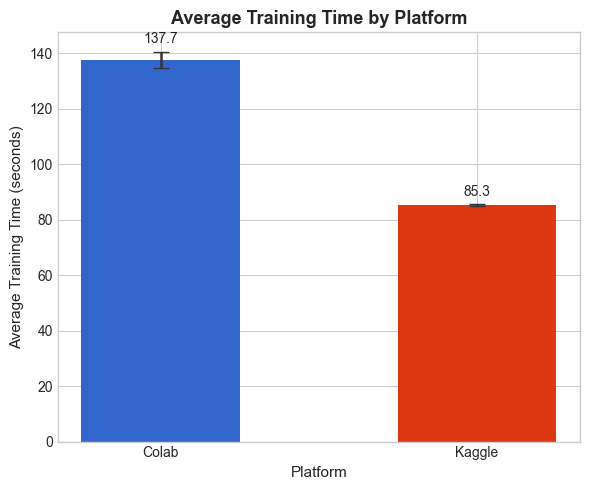

In [19]:
plat_mean = df.groupby(["platform", "repeat_idx"])["total_train_time_s"].mean().reset_index()
plat_ci   = plat_mean.groupby("platform")["total_train_time_s"].agg(["mean", ci95]).rename(columns={"mean": "Mean", "ci95": "CI"})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    plat_ci.index, plat_ci["Mean"],
    color=[COLORS[p] for p in plat_ci.index],
    yerr=plat_ci["CI"], capsize=6,
    error_kw={"elinewidth": 1.8, "ecolor": "#333333"},
    width=0.5,
)
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=10)
ax.set_title("Average Training Time by Platform", fontsize=13, fontweight="bold")
ax.set_xlabel("Platform", fontsize=11)
ax.set_ylabel("Average Training Time (seconds)", fontsize=11)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("platform_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Graph 2 – CPU vs GPU Training Time by Platform

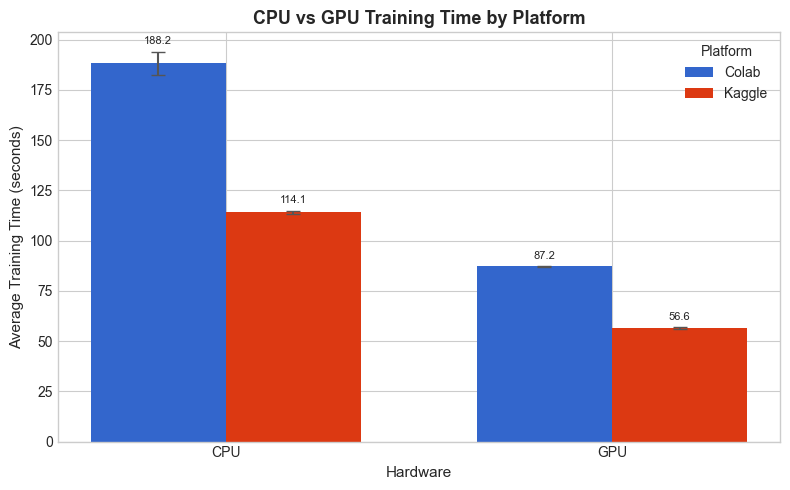

In [20]:
# mean per (device, platform, repeat), then aggregate across repeats for CI
hw_rep = df.groupby(["device_label", "platform", "repeat_idx"])["total_train_time_s"].mean().reset_index()

hw_mean = hw_rep.groupby(["device_label", "platform"])["total_train_time_s"].mean().unstack().reindex(index=["CPU", "GPU"], columns=["Colab", "Kaggle"])
hw_ci   = hw_rep.groupby(["device_label", "platform"])["total_train_time_s"].apply(ci95).unstack().reindex(index=["CPU", "GPU"], columns=["Colab", "Kaggle"])

grouped_bar_ci(
    hw_mean, hw_ci,
    "CPU vs GPU Training Time by Platform",
    "Hardware", "Average Training Time (seconds)",
    "cpu_vs_gpu_comparison.png",
)

## 6. Graph 3 – Model Comparison by Platform

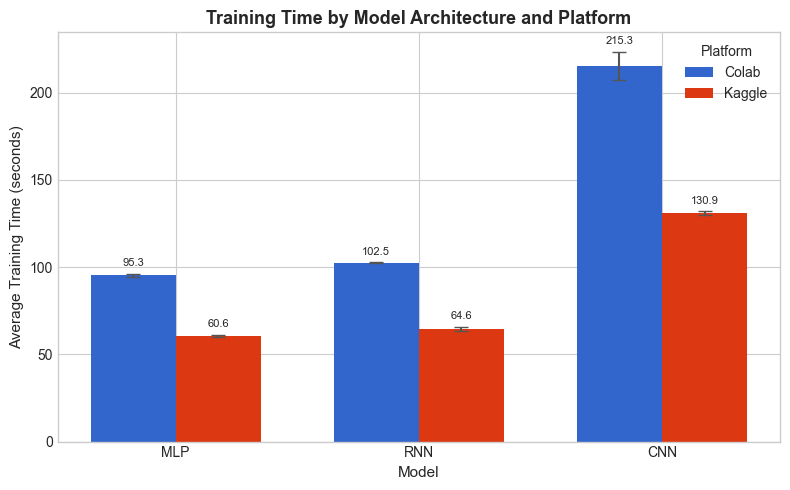

In [21]:
model_rep = df.groupby(["model", "platform", "repeat_idx"])["total_train_time_s"].mean().reset_index()

model_mean = model_rep.groupby(["model", "platform"])["total_train_time_s"].mean().unstack().reindex(index=["MLP", "RNN", "CNN"], columns=["Colab", "Kaggle"])
model_ci   = model_rep.groupby(["model", "platform"])["total_train_time_s"].apply(ci95).unstack().reindex(index=["MLP", "RNN", "CNN"], columns=["Colab", "Kaggle"])

grouped_bar_ci(
    model_mean, model_ci,
    "Training Time by Model Architecture and Platform",
    "Model", "Average Training Time (seconds)",
    "model_comparison.png",
)

## 7. Graph 4 – Dataset Size Effect by Platform

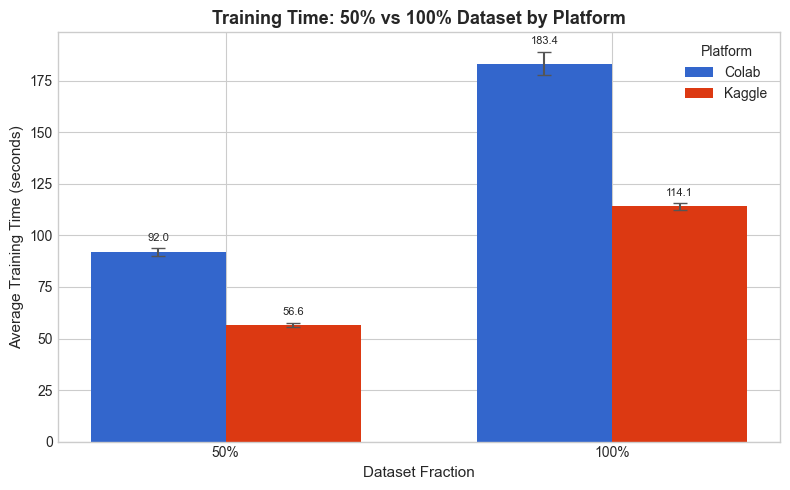

In [22]:
ds_rep = df.groupby(["dataset_label", "platform", "repeat_idx"])["total_train_time_s"].mean().reset_index()

ds_mean = ds_rep.groupby(["dataset_label", "platform"])["total_train_time_s"].mean().unstack().reindex(index=["50%", "100%"], columns=["Colab", "Kaggle"])
ds_ci   = ds_rep.groupby(["dataset_label", "platform"])["total_train_time_s"].apply(ci95).unstack().reindex(index=["50%", "100%"], columns=["Colab", "Kaggle"])

grouped_bar_ci(
    ds_mean, ds_ci,
    "Training Time: 50% vs 100% Dataset by Platform",
    "Dataset Fraction", "Average Training Time (seconds)",
    "dataset_size_comparison.png",
)

## 8. Graph 5 – GPU Speedup over CPU (by Model and Platform)

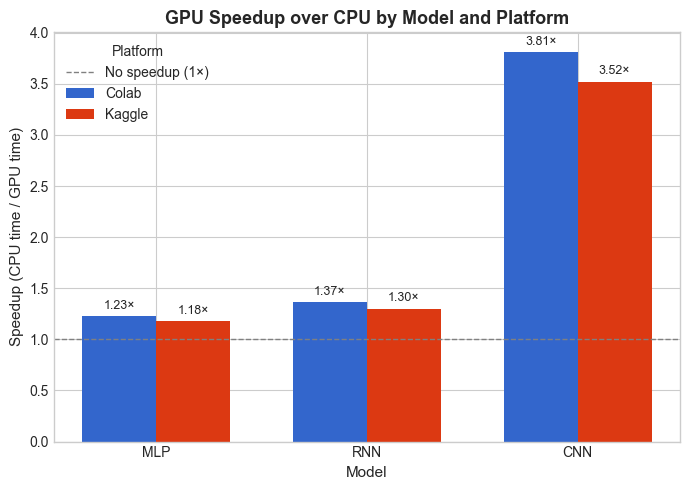


Speedup table:
platform  Colab  Kaggle
model                  
MLP        1.23    1.18
RNN        1.37    1.30
CNN        3.81    3.52


In [23]:
# speedup = mean CPU time / mean GPU time  (per model × platform)
hw_model = (
    df.groupby(["platform", "device_label", "model"])["total_train_time_s"]
    .mean()
    .unstack(level="device_label")
)
hw_model["speedup"] = hw_model["CPU"] / hw_model["GPU"]
speedup_table = hw_model["speedup"].unstack(level="platform").reindex(index=["MLP", "RNN", "CNN"], columns=["Colab", "Kaggle"])

fig, ax = plt.subplots(figsize=(7, 5))
x     = np.arange(len(speedup_table))
width = 0.35
for i, col in enumerate(["Colab", "Kaggle"]):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, speedup_table[col], width, label=col, color=COLORS[col])
    ax.bar_label(bars, fmt="%.2f×", padding=3, fontsize=9)

ax.axhline(1, color="grey", linestyle="--", linewidth=1, label="No speedup (1×)")
ax.set_title("GPU Speedup over CPU by Model and Platform", fontsize=13, fontweight="bold")
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Speedup (CPU time / GPU time)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(speedup_table.index)
ax.legend(title="Platform")
plt.tight_layout()
plt.savefig("gpu_speedup.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSpeedup table:")
print(speedup_table.round(2))

## 9. Graph 6 – Throughput Comparison (Samples / Second)

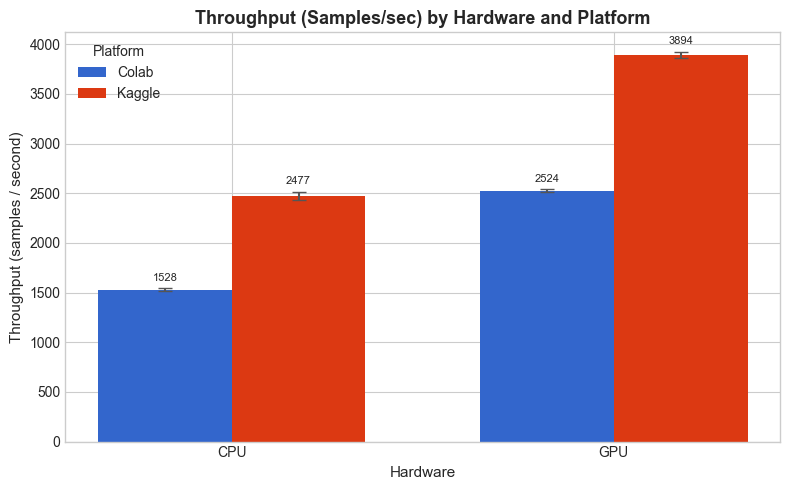

In [24]:
tp_rep = df.groupby(["device_label", "platform", "repeat_idx"])["throughput_samples_per_s"].mean().reset_index()

tp_mean = tp_rep.groupby(["device_label", "platform"])["throughput_samples_per_s"].mean().unstack().reindex(index=["CPU", "GPU"], columns=["Colab", "Kaggle"])
tp_ci   = tp_rep.groupby(["device_label", "platform"])["throughput_samples_per_s"].apply(ci95).unstack().reindex(index=["CPU", "GPU"], columns=["Colab", "Kaggle"])

grouped_bar_ci(
    tp_mean, tp_ci,
    "Throughput (Samples/sec) by Hardware and Platform",
    "Hardware", "Throughput (samples / second)",
    "throughput_comparison.png",
    fmt="%.0f",
)

## 10. Graph 7 – Scalability: 50 % → 100 % Dataset Scaling Ratio

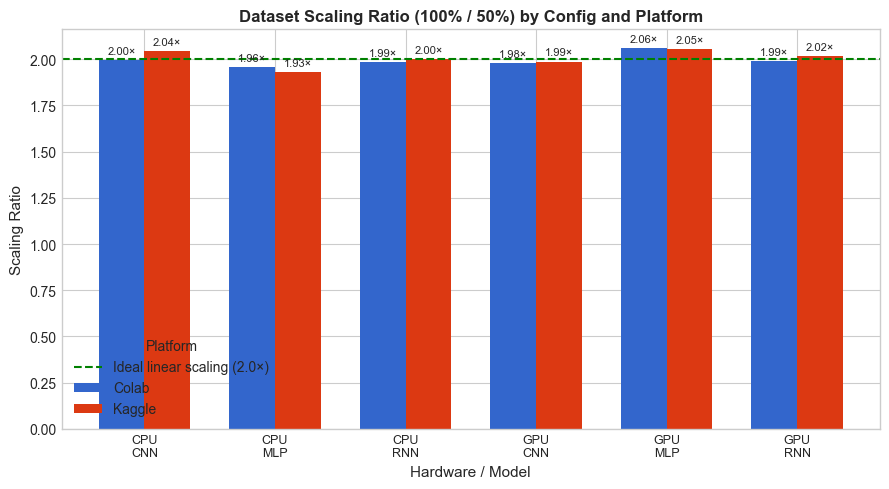


Scaling ratio table (≈2.0 = near-linear):
platform            Colab  Kaggle
device_label model               
CPU          CNN    1.997   2.043
             MLP    1.960   1.932
             RNN    1.986   2.001
GPU          CNN    1.978   1.988
             MLP    2.059   2.055
             RNN    1.991   2.019


In [25]:
# near-linear scaling → ratio ≈ 2.0
scale = (
    df.groupby(["platform", "device_label", "model", "dataset_label"])["total_train_time_s"]
    .mean()
    .unstack(level="dataset_label")
)
scale["scaling_ratio"] = scale["100%"] / scale["50%"]
scale_plot = (
    scale["scaling_ratio"]
    .reset_index()
    .pivot_table(index=["device_label", "model"], columns="platform", values="scaling_ratio")
    .reindex(columns=["Colab", "Kaggle"])
)

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(scale_plot))
width = 0.35
for i, col in enumerate(["Colab", "Kaggle"]):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, scale_plot[col], width, label=col, color=COLORS[col])
    ax.bar_label(bars, fmt="%.2f×", padding=3, fontsize=8)

ax.axhline(2.0, color="green", linestyle="--", linewidth=1.5, label="Ideal linear scaling (2.0×)")
ax.set_title("Dataset Scaling Ratio (100% / 50%) by Config and Platform", fontsize=12, fontweight="bold")
ax.set_xlabel("Hardware / Model", fontsize=11)
ax.set_ylabel("Scaling Ratio", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([f"{d}\n{m}" for d, m in scale_plot.index], fontsize=9)
ax.legend(title="Platform")
plt.tight_layout()
plt.savefig("scalability_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nScaling ratio table (≈2.0 = near-linear):")
print(scale_plot.round(3))

## 11. Graph 8 – Performance Variability (Coefficient of Variation)

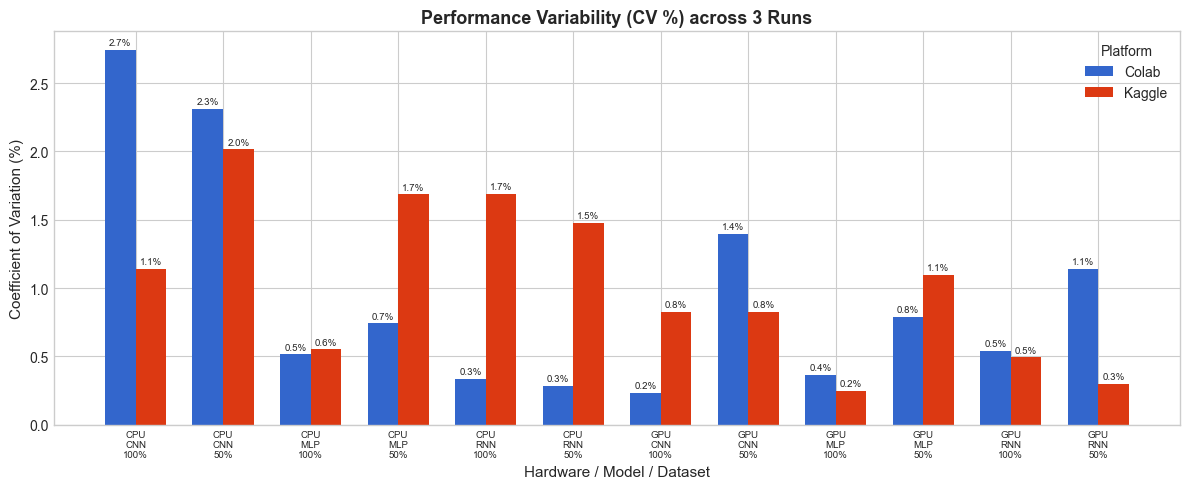

In [26]:
# CV (%) = (std / mean) × 100 ;; lower = more stable
var_df = (
    df.groupby(["platform", "device_label", "model", "dataset_label"])["total_train_time_s"]
    .agg(["mean", "std"])
    .assign(cv=lambda x: (x["std"] / x["mean"]) * 100)
    .reset_index()
)

cv_plot = (
    var_df.pivot_table(index=["device_label", "model", "dataset_label"], columns="platform", values="cv")
    .reindex(columns=["Colab", "Kaggle"])
)

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(cv_plot))
width = 0.35
for i, col in enumerate(["Colab", "Kaggle"]):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, cv_plot[col], width, label=col, color=COLORS[col])
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=7)

ax.set_title("Performance Variability (CV %) across 3 Runs", fontsize=13, fontweight="bold")
ax.set_xlabel("Hardware / Model / Dataset", fontsize=11)
ax.set_ylabel("Coefficient of Variation (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{d}\n{m}\n{ds}" for d, m, ds in cv_plot.index],
    fontsize=7,
)
ax.legend(title="Platform")
plt.tight_layout()
plt.savefig("variability_cv.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Graph 9 – Per-Epoch Training Time by Model (GPU only)

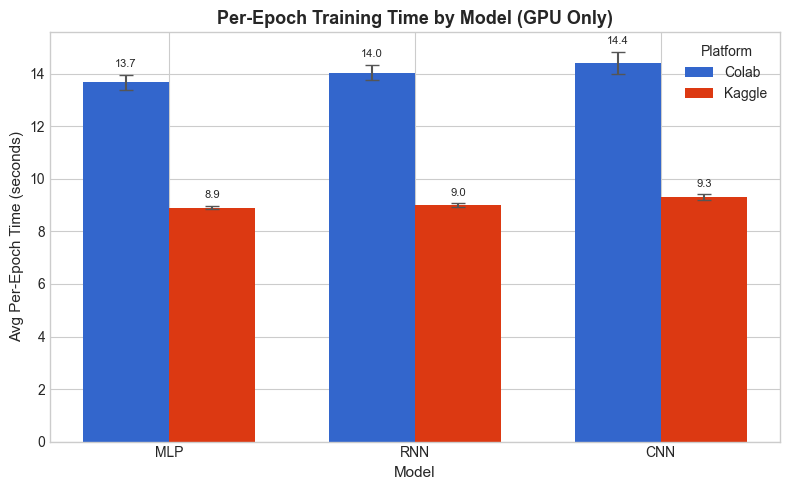

In [27]:
gpu_df = df[df["device_label"] == "GPU"]

epoch_rep = gpu_df.groupby(["model", "platform", "repeat_idx"])["per_epoch_time_s_mean"].mean().reset_index()
epoch_mean = epoch_rep.groupby(["model", "platform"])["per_epoch_time_s_mean"].mean().unstack().reindex(index=["MLP", "RNN", "CNN"], columns=["Colab", "Kaggle"])
epoch_ci   = epoch_rep.groupby(["model", "platform"])["per_epoch_time_s_mean"].apply(ci95).unstack().reindex(index=["MLP", "RNN", "CNN"], columns=["Colab", "Kaggle"])

grouped_bar_ci(
    epoch_mean, epoch_ci,
    "Per-Epoch Training Time by Model (GPU Only)",
    "Model", "Avg Per-Epoch Time (seconds)",
    "per_epoch_time_gpu.png",
)

## 13. Summary Statistics Table (for the Report)

In [28]:
summary = agg[[
    "platform", "device_label", "model", "dataset_label",
    "mean_total_time", "std_total_time", "ci_total_time",
    "mean_throughput", "std_throughput",
    "mean_val_acc", "mean_test_acc",
]].rename(columns={
    "platform":        "Platform",
    "device_label":    "Hardware",
    "model":           "Model",
    "dataset_label":   "Dataset",
    "mean_total_time": "Mean Time (s)",
    "std_total_time":  "Std (s)",
    "ci_total_time":   "95% CI ±",
    "mean_throughput": "Throughput (samp/s)",
    "std_throughput":  "Throughput Std",
    "mean_val_acc":    "Val Acc (%)",
    "mean_test_acc":   "Test Acc (%)",
}).sort_values(["Platform", "Hardware", "Model", "Dataset"]).round(2)

summary.to_csv("summary_statistics.csv", index=False)
summary

,Platform,Hardware,Model,Dataset,Mean Time (s),Std (s),95% CI ±,Throughput (samp/s),Throughput Std,Val Acc (%),Test Acc (%)
0,Colab,CPU,CNN,100%,454.53,12.46,30.95,645.00,17.97,89.95,88.51
1,Colab,CPU,CNN,50%,227.58,5.27,13.08,644.00,14.90,88.31,86.46
2,Colab,CPU,MLP,100%,139.18,0.72,1.78,2105.36,10.82,79.95,77.13
3,Colab,CPU,MLP,50%,71.03,0.53,1.31,2062.82,15.38,77.11,73.89
4,Colab,CPU,RNN,100%,157.35,0.53,1.32,1862.23,6.28,59.89,58.30
5,Colab,CPU,RNN,50%,79.25,0.22,0.56,1848.72,5.22,52.43,50.43
6,Colab,GPU,CNN,100%,118.83,0.28,0.68,2465.88,5.71,90.01,88.11
7,Colab,GPU,CNN,50%,60.07,0.84,2.09,2439.44,34.25,88.11,85.90
8,Colab,GPU,MLP,100%,115.03,0.42,1.05,2547.44,9.37,80.04,76.97
9,Colab,GPU,MLP,50%,55.88,0.44,1.09,2622.13,20.67,77.82,74.12


## 14. Key Findings

In [29]:
overall = df.groupby("platform")["total_train_time_s"].mean()
hw      = df.groupby(["platform", "device_label"])["total_train_time_s"].mean()
model_t = df.groupby(["platform", "model"])["total_train_time_s"].mean()
ds_t    = df.groupby(["platform", "dataset_label"])["total_train_time_s"].mean()

colab_speedup  = hw["Colab",  "CPU"] / hw["Colab",  "GPU"]
kaggle_speedup = hw["Kaggle", "CPU"] / hw["Kaggle", "GPU"]

print("=" * 60)
print("PLATFORM COMPARISON")
print(f"  Colab  overall avg : {overall['Colab']:.1f} s")
print(f"  Kaggle overall avg : {overall['Kaggle']:.1f} s")
print(f"  Kaggle is {overall['Colab']/overall['Kaggle']:.2f}× faster than Colab overall")

print("\nHARDWARE ACCELERATION")
print(f"  Colab  – CPU: {hw['Colab','CPU']:.1f}s  GPU: {hw['Colab','GPU']:.1f}s  → speedup {colab_speedup:.2f}×")
print(f"  Kaggle – CPU: {hw['Kaggle','CPU']:.1f}s  GPU: {hw['Kaggle','GPU']:.1f}s  → speedup {kaggle_speedup:.2f}×")

print("\nMODEL COMPLEXITY")
for plat in ["Colab", "Kaggle"]:
    for m in ["MLP", "RNN", "CNN"]:
        print(f"  {plat} {m}: {model_t[plat, m]:.1f} s")

print("\nDATASET SCALABILITY")
for plat in ["Colab", "Kaggle"]:
    ratio = ds_t[plat, "100%"] / ds_t[plat, "50%"]
    print(f"  {plat}: 50%={ds_t[plat,'50%']:.1f}s  100%={ds_t[plat,'100%']:.1f}s  ratio={ratio:.2f}×")

print("=" * 60)

PLATFORM COMPARISON
  Colab  overall avg : 137.7 s
  Kaggle overall avg : 85.3 s
  Kaggle is 1.61× faster than Colab overall

HARDWARE ACCELERATION
  Colab  – CPU: 188.2s  GPU: 87.2s  → speedup 2.16×
  Kaggle – CPU: 114.1s  GPU: 56.6s  → speedup 2.02×

MODEL COMPLEXITY
  Colab MLP: 95.3 s
  Colab RNN: 102.5 s
  Colab CNN: 215.3 s
  Kaggle MLP: 60.6 s
  Kaggle RNN: 64.6 s
  Kaggle CNN: 130.9 s

DATASET SCALABILITY
  Colab: 50%=92.0s  100%=183.4s  ratio=1.99×
  Kaggle: 50%=56.6s  100%=114.1s  ratio=2.01×
